All Angles from 0 degree to 180 degrees

In [ ]:
!pip install samna

!pip install sinabs

!pip install sinabs.exodus

!pip install torch

!pip install torchmetrics

!pip install tonic

!pip install tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.3/107.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for sinabs.exodus: filename=sinabs_exodus-1.2.1-cp310-cp310-linux_x86_64.whl size=420471 sha256=9123c5c571c1159e00f3fb733f00f09ad12e9b2c3bbe3f291a327bd3f1099d1c
  Stored in directory: /root/.cache/pip/wheels/ae/20/1a/a9374c24a582cd8587ff6c709bcdc3d7ec3a35b617121ec34b
Successfully built sinabs.exodus
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.2/866.2 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 4.8 MB/s eta 0:00:00


In [ ]:
import torch
import sinabs
import sinabs.layers as sl
import sinabs.exodus.layers as sel
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sinabs.exodus.conversion import exodus_to_sinabs
from google.colab import drive
import os
import pickle
from sklearn.model_selection import train_test_split
import torchmetrics
import pickle
from tqdm import tqdm
import pandas as pd
import struct
from tonic.dataset import Dataset
from tonic.io import make_structured_array
from typing import Callable, Optional
from tonic import transforms
import torch
from torch.utils.data import DataLoader


In [ ]:
angle_to_class = {
    0: 0, 15: 1, 30: 2, 45: 3, 60: 4,
    75: 5, 90: 6, 105: 7, 120: 8,
    135: 9, 150: 10, 165: 11
}


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

"""***PATH***"""

data_dir = '/content/drive/My Drive/DatasetCombinedRaw'
file_path = '/content/rot_90_995.pickle'  #Per File Checking
train_data_path = os.path.join(data_dir, 'train_data.pickle')
test_data_path = os.path.join(data_dir, 'test_data.pickle')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def conversion(file_path):

  f = open(file_path, "rb")
  event_dtype = np.dtype([("address", "<u4"), ("timeStamp", "<u4")])
  final_dtype = np.dtype([("x", np.int16), ("y", np.int16), ("t", np.int64), ("p", np.int8)])
  event_list = []
  while True:
    header = f.read(28)
    if not header or len(header) == 0:
      break

    # read header
    capacity = struct.unpack("I", header[16:20])[0]
    event_list.append(np.fromfile(f, event_dtype, capacity))
  all_events = np.concatenate(event_list)
  f.close()

  all_addr = all_events["address"]
  t = all_events["timeStamp"]

  x = (all_addr >> 8) & 0x007F
  y = (all_addr >> 1) & 0x007F
  p = all_addr & 0x1

  sensor_size = (128, 128, 2)
  xytp = make_structured_array(x, y, t, p, dtype=final_dtype)
  shape = (128, 128)
  return xytp

file_path = os.path.join(data_dir, "Train")
for path, dirs, files in os.walk(file_path):
    files.sort()
    for file in files:
        if file.endswith("pickle"):
            # print(path + "/" + file)
            print(path.split("/")[-1])


75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
75
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120
120


In [ ]:
class SNN(Dataset):


    base_url = data_dir

    train_folder = "Train"

    test_folder = "Test"


    sensor_size = (128, 128, 2)
    # dtype = np.dtype([("x", int), ("y", int), ("t", int), ("p", int)])
    # ordering = dtype.names

    def __init__(
        self,
        train: bool = True,
        stabilize: bool = False,
        transform: Optional[Callable] = None,
        target_transform: Optional[Callable] = None,
        transforms: Optional[Callable] = None,
    ):
        super().__init__(
            save_to='',
            transform=transform,
            target_transform=target_transform,
            transforms=transforms,
        )
        self.train = train
        self.stabilize = stabilize

        if train:
            self.url = self.base_url
            self.folder_name = self.train_folder
        else:
            self.url = self.base_url
            self.folder_name = self.test_folder

        # if not self._check_exists():
        #     self.download()

        file_path = os.path.join(self.url, self.folder_name)
        for path, dirs, files in os.walk(file_path):
            files.sort()
            for file in files:
                if file.endswith("pickle"):
                    self.data.append(path + "/" + file)
                    label_number = int(path.split("/")[-1])
                    self.targets.append(label_number)

    def __getitem__(self, index):
        """
        Returns:
            a tuple of (events, target) where target is the index of the target
            class.
        """
        events = conversion(self.data[index])
        target = self.targets[index]
        if self.transform is not None:
            events = self.transform(events)
        if self.target_transform is not None:
            target = self.target_transform(target)
        if self.transforms is not None:
            events, target = self.transforms(events, target)
        return events, target


    def __len__(self) -> int:
        return len(self.data)


    def _check_exists(self) -> bool:
        return (
            self._is_file_present()
            and self._folder_contains_at_least_n_files_of_type(10000, ".bin")
        )

In [ ]:
sensor_size = (128, 128, 2)

In [ ]:
from tonic import transforms

transform = transforms.Compose([
    transforms.ToFrame(sensor_size=sensor_size, n_time_bins=30, include_incomplete=True),
    lambda x: x.astype(np.float32),
])

In [ ]:
snn_train = SNN(train=True, transform=transform)
snn_test = SNN(train=False, transform=transform)

In [ ]:
snn_train[10]
#snn_test[141]

(array([[[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],
 
         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]]],
 
 
        [[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],
 
         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ...

In [ ]:
trainloader = torch.utils.data.DataLoader(snn_train, batch_size=16, shuffle=True, num_workers=4, drop_last=True)
testloader = torch.utils.data.DataLoader(snn_test, batch_size=16, shuffle=True, num_workers=4, drop_last=True)

# Get a batch of data
data_iter = iter(trainloader)
inputs, _ = next(data_iter)

# Print shape and data type of inputs
print("Input shape:", inputs.shape)
print("Input data type:", inputs.dtype)

Input shape: torch.Size([16, 30, 2, 128, 128])
Input data type: torch.float32


In [ ]:
trainloader
testloader

In [ ]:
frames = next(iter(trainloader))[0]
frames.shape

try:
  frames_test = next(iter(testloader))[0]
  frames_test.shape
except:
  frames_test = None

frames_test


tensor([[[[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           ...,
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00]],

          [[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
            0.0000e+00, 0.0000e+00],
           ...,
           [0.0000e+00, 0.0000e+00, 0.0

In [ ]:
frames.shape

torch.Size([16, 30, 2, 128, 128])

In [ ]:
import sinabs.exodus.layers as sel

batch_size = 16

#backend = sl # Sinabs
backend = sel # Sinabs EXODUS

model = nn.Sequential(
    sl.FlattenTime(),
    nn.Conv2d(2, 8, kernel_size=3, padding=1, bias=False),
    backend.IAFSqueeze(batch_size=batch_size, min_v_mem=-1),
    sl.SumPool2d(2),
    nn.Conv2d(8, 16, kernel_size=3, padding=1, bias=False),
    backend.IAFSqueeze(batch_size=batch_size, min_v_mem=-1),
    sl.SumPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False),
    backend.IAFSqueeze(batch_size=batch_size, min_v_mem=-1),
    sl.SumPool2d(2),
    nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
    backend.IAFSqueeze(batch_size=batch_size, min_v_mem=-1),
    sl.SumPool2d(2),
    nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
    backend.IAFSqueeze(batch_size=batch_size, min_v_mem=-1),
    sl.SumPool2d(2),
    nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
    backend.IAFSqueeze(batch_size=batch_size, min_v_mem=-1),
    sl.SumPool2d(2),
    nn.Conv2d(256, 12, kernel_size=2, padding=0, bias=False),
    backend.IAFSqueeze(batch_size=batch_size, min_v_mem=-1),
    nn.Flatten(),
    sl.UnflattenTime(batch_size=batch_size),
).cuda()

In [ ]:
model(frames.cuda()).shape

torch.Size([16, 30, 12])

In [ ]:
%env CUDA_LAUNCH_BLOCKING=1


env: CUDA_LAUNCH_BLOCKING=1


In [ ]:
n_epochs = 4
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
crit = nn.functional.cross_entropy

for epoch in range(n_epochs):
    losses = []
    for data, targets in tqdm(trainloader):
        # Debugging: Print raw targets before any conversion
        print(f"Epoch: {epoch}, Raw targets before conversion: {targets}")

        # Convert angle targets to class indices using the defined dictionary
        try:
            targets = torch.tensor([angle_to_class[target.item()] for target in targets], dtype=torch.long)
        except KeyError as e:
            print(f"Encountered an invalid angle during conversion: {e}")
            continue

        # Check for out-of-range values before moving to GPU
        if targets.max().item() >= 12:
            print(f"Invalid target value detected. Skipping batch with targets: {targets}")
            continue  # Skip this batch if invalid targets are found

        # Move data and targets to GPU
        data, targets = data.cuda(), targets.cuda()

        # Debugging: Print shapes and unique target values on GPU
        print(f"Epoch: {epoch}, data shape: {data.shape}, targets shape: {targets.shape}")
        print(f"Unique target values on GPU: {targets.unique()}")

        sinabs.reset_states(model)
        optimizer.zero_grad()

        # Forward pass
        y_hat = model(data)

        # Debugging: Check output shape
        print(f"y_hat shape: {y_hat.shape}")

        # Sum over the time dimension
        pred = y_hat.sum(1)

        # Debugging: Print shapes before loss computation
        print(f"pred shape: {pred.shape}, targets shape: {targets.shape}")

        # Compute the loss
        loss = crit(pred, targets)

        # Debugging: Print loss value
        print(f"Loss: {loss.item()}")

        # Backward pass and optimization
        loss.backward()
        losses.append(loss)
        optimizer.step()

    # Compute and print the average loss for the epoch
    print(f"Epoch {epoch} - Average Loss: {torch.stack(losses).mean()}")


  0%|          | 0/111 [00:00<?, ?it/s]

Epoch: 0, Raw targets before conversion: tensor([135, 120,  60,  75,  45, 105, 105,  90, 135, 150,   0, 150,  45,  45,
         15,  90])
Epoch: 0, data shape: torch.Size([16, 30, 2, 128, 128]), targets shape: torch.Size([16])
Unique target values on GPU: tensor([ 0,  1,  3,  4,  5,  6,  7,  8,  9, 10], device='cuda:0')


  1%|          | 1/111 [00:01<03:04,  1.68s/it]

y_hat shape: torch.Size([16, 30, 12])
pred shape: torch.Size([16, 12]), targets shape: torch.Size([16])
Loss: 96.99858856201172
Epoch: 0, Raw targets before conversion: tensor([ 60,  15, 105,  60,  45,   0,   0,  30,  30, 135, 165,  60,  30,   0,
        135,  45])
Epoch: 0, data shape: torch.Size([16, 30, 2, 128, 128]), targets shape: torch.Size([16])
Unique target values on GPU: tensor([ 0,  1,  2,  3,  4,  7,  9, 11], device='cuda:0')


  2%|▏         | 2/111 [00:02<02:01,  1.12s/it]

...

 99%|█████████▉| 110/111 [01:07<00:00,  1.86it/s]

y_hat shape: torch.Size([16, 30, 12])
pred shape: torch.Size([16, 12]), targets shape: torch.Size([16])
Loss: 2.4849066734313965
Epoch: 3, Raw targets before conversion: tensor([105, 135, 120,  15,  45,  90, 150,   0, 150,  75,  30,   0, 105, 120,
         45, 135])
Epoch: 3, data shape: torch.Size([16, 30, 2, 128, 128]), targets shape: torch.Size([16])
Unique target values on GPU: tensor([ 0,  1,  2,  3,  5,  6,  7,  8,  9, 10], device='cuda:0')


100%|██████████| 111/111 [01:07<00:00,  1.63it/s]

y_hat shape: torch.Size([16, 30, 12])
pred shape: torch.Size([16, 12]), targets shape: torch.Size([16])
Loss: 2.4849066734313965


Epoch 3 - Average Loss: 2.485517978668213


In [ ]:
import torchmetrics
from torch import nn
from tqdm import tqdm

# Define accuracy metric
acc = torchmetrics.Accuracy('multiclass', num_classes=12).cuda()

# Set model to evaluation mode
model.eval()
#linear_layer = nn.Linear(637, 13).cuda()

# Angle to Class
angle_to_class = {
    0: 0, 15: 1, 30: 2, 45: 3, 60: 4,
    75: 5, 90: 6, 105: 7, 120: 8,
    135: 9, 150: 10, 165: 11
}

#}

# Testing loop
for data, targets in tqdm(testloader):
    # Convert angle targets to class indices
    targets = torch.tensor([angle_to_class[target.item()] for target in targets])

    # Move data and targets to GPU
    data, targets = data.cuda(), targets.cuda()

    # Reset model states and disable gradient calculation for evaluation
    sinabs.reset_states(model)
    with torch.no_grad():
        # Forward pass
        y_hat = model(data)

    # Sum over the time dimension
    pred = y_hat.sum(dim=1)

    # Apply the linear layer to match the output to the number of classes
    #pred = linear_layer(pred)

    # Compute accuracy
    acc.update(pred, targets)

# Compute and print the final accuracy
final_accuracy = acc.compute()
print(f"Test Accuracy: {final_accuracy.item()}")


100%|██████████| 27/27 [00:38<00:00,  1.41s/it]

Test Accuracy: 0.0833333358168602


In [ ]:
# Compute and print the final accuracy
final_accuracy = acc.compute()
print(f"Test Accuracy: {final_accuracy.item() * 100:.2f}%")

Test Accuracy: 8.33%


In [ ]:
import torch

if torch.cuda.is_available():
    print(f"GPU is available. Device name: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU available.")


GPU is available. Device name: Tesla T4


In [ ]:
!pip install scikit-learn seaborn


  0%|          | 0/27 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
100%|██████████| 27/27 [00:14<00:00,  1.82it/s]


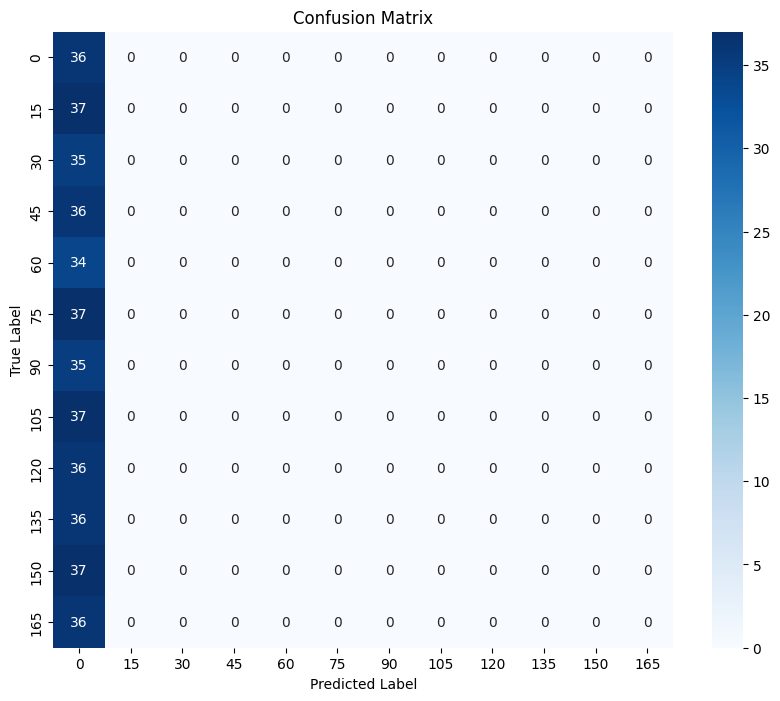

Classification Report:
              precision    recall  f1-score   support

           0       0.08      1.00      0.15        36
          15       0.00      0.00      0.00        37
          30       0.00      0.00      0.00        35
          45       0.00      0.00      0.00        36
          60       0.00      0.00      0.00        34
          75       0.00      0.00      0.00        37
          90       0.00      0.00      0.00        35
         105       0.00      0.00      0.00        37
         120       0.00      0.00      0.00        36
         135       0.00      0.00      0.00        36
         150       0.00      0.00      0.00        37
         165       0.00      0.00      0.00        36

    accuracy                           0.08       432
   macro avg       0.01      0.08      0.01       432
weighted avg       0.01      0.08      0.01       432

Overall Accuracy: 8.33%


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import torch
import torchmetrics
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize accuracy metric
acc = torchmetrics.Accuracy('multiclass', num_classes=12).cuda()

# Initialize lists to store true labels and predictions
all_preds = []
all_targets = []

# Set model to evaluation mode
model.eval()

# Testing loop
for data, targets in tqdm(testloader):
    # Convert angle targets to class indices using the defined dictionary
    targets = torch.tensor([angle_to_class[target.item()] for target in targets])

    # Move data and targets to GPU
    data, targets = data.cuda(), targets.cuda()

    # Reset model states and disable gradient calculation for evaluation
    sinabs.reset_states(model)
    with torch.no_grad():
        # Forward pass
        y_hat = model(data)

    # Sum over the time dimension (ensure this is correct for your model)
    pred = y_hat.sum(dim=1)

    # Get predicted classes
    predicted_classes = pred.argmax(dim=1)

    # Store predictions and true labels
    all_preds.extend(predicted_classes.cpu().numpy())
    all_targets.extend(targets.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_targets, all_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=angle_to_class.keys(), yticklabels=angle_to_class.keys())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(all_targets, all_preds, target_names=[str(angle) for angle in angle_to_class.keys()]))

# Calculate and print overall accuracy
accuracy = accuracy_score(all_targets, all_preds)
print(f"Overall Accuracy: {accuracy:.2%}")
